RAILPULSE-AI - STATION CROWD PREDICTION

Dataset loaded successfully!
Shape: (5000, 10)

COLUMNS
['date', 'station', 'hour', 'day_of_week', 'holiday', 'train_frequency', 'passenger_count', 'entry_count', 'exit_count', 'crowd_level']

FIRST 5 ROWS
         date     station  hour  day_of_week  holiday  train_frequency  \
0  2025-04-15     Kurnool     9            1        0                3   
1  2025-06-30    Tirupati     2            0        0                8   
2  2025-02-15     Nellore     0            5        0                7   
3  2025-10-14  Vijayawada    15            1        0               12   
4  2025-09-19    Warangal     9            4        0                4   

   passenger_count  entry_count  exit_count crowd_level  
0              139          106          31         Low  
1              667          386         394         Low  
2             1312          723         664      Medium  
3             1390         1045         461      Medium  
4              975

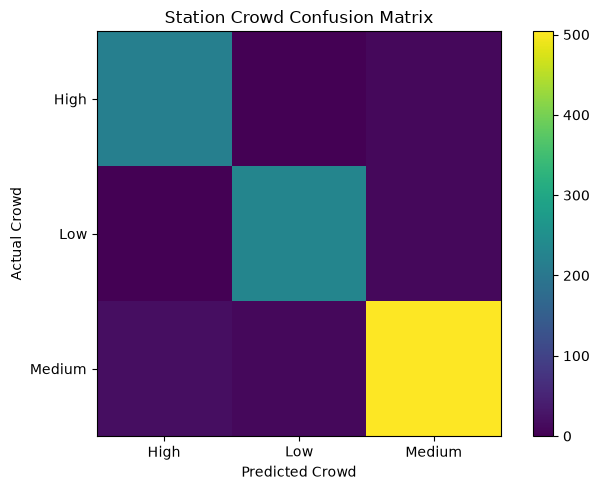


FEATURE IMPORTANCE
        Feature  Importance
passenger_count      0.1789
train_frequency      0.1629
   is_peak_hour      0.1526
    entry_count      0.1156
     exit_count      0.0984
        holiday      0.0725
           hour      0.0694
    day_of_week      0.0437
     is_weekend      0.0330
            day      0.0289
          month      0.0224
station_encoded      0.0217
           year      0.0000


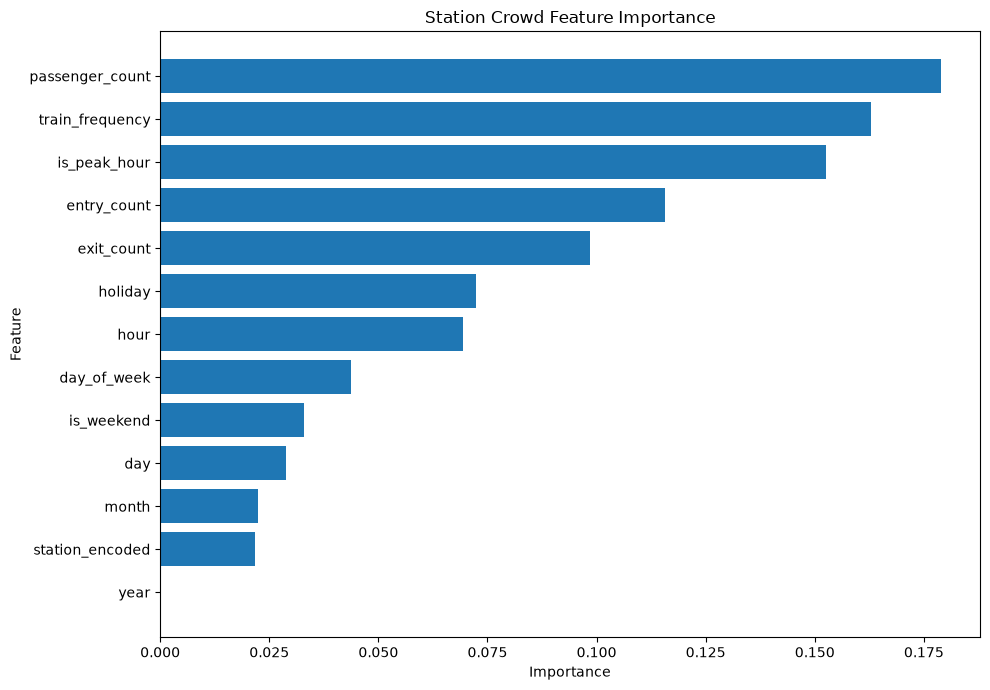


SAMPLE STATION CROWD PREDICTIONS
Actual_Crowd Predicted_Crowd
        High            High
        High            High
      Medium          Medium
      Medium          Medium
      Medium          Medium
      Medium          Medium
        High            High
         Low             Low
        High            High
      Medium          Medium
         Low             Low
        High            High
         Low             Low
      Medium          Medium
      Medium          Medium

MODEL SAVED
Model path: c:\Users\Dell\RailPulse-AI\RailPulse-AI\models\crowd\station_crowd.pkl
Predictions saved: c:\Users\Dell\RailPulse-AI\RailPulse-AI\data\processed\station_crowd_predictions.csv
Feature importance saved: c:\Users\Dell\RailPulse-AI\RailPulse-AI\data\processed\station_crowd_feature_importance.csv


🎉 08 STATION CROWD PREDICTION COMPLETED!
Dataset: (5000, 16)
Accuracy: 95.0 %
Model: ../models/crowd/station_crowd.pkl
Predictions: ../data/processed/station_crowd_predictions.csv


In [10]:
# ============================================================
# RAILPULSE-AI
# 08 - STATION CROWD PREDICTION
# ============================================================

import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("============================================================")
print("RAILPULSE-AI - STATION CROWD PREDICTION")
print("============================================================")


# ============================================================
# 1. LOAD DATA
# ============================================================

# Current notebook location:
# RailPulse-AI/RailPulse-AI/notebooks
#
# Raw data location:
# RailPulse-AI/RailPulse-AI/data/raw

DATA_PATH = "../data/raw/station_crowd.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"\nDataset not found!\n"
        f"Expected path: {os.path.abspath(DATA_PATH)}"
    )

df = pd.read_csv(DATA_PATH)


print("\nDataset loaded successfully!")
print("Shape:", df.shape)


# ============================================================
# 2. DISPLAY DATA
# ============================================================

print("\n============================================================")
print("COLUMNS")
print("============================================================")

print(df.columns.tolist())


print("\n============================================================")
print("FIRST 5 ROWS")
print("============================================================")

print(df.head())


print("\n============================================================")
print("DATA TYPES")
print("============================================================")

print(df.dtypes)


# ============================================================
# 3. CHECK DATASET
# ============================================================

print("\n============================================================")
print("DATA INFORMATION")
print("============================================================")

df.info()


print("\n============================================================")
print("MISSING VALUES")
print("============================================================")

print(df.isnull().sum())


# ============================================================
# 4. REMOVE DUPLICATES
# ============================================================

before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

after = len(df)

print("\nDuplicates removed:", before - after)
print("Current shape:", df.shape)


# ============================================================
# 5. CHECK TARGET
# ============================================================

TARGET = "crowd_level"

if TARGET not in df.columns:

    raise ValueError(
        f"Target column '{TARGET}' not found.\n"
        f"Available columns: {df.columns.tolist()}"
    )


print("\n============================================================")
print("TARGET COLUMN")
print("============================================================")

print("Target:", TARGET)

print("\nTarget values:")

print(
    df[TARGET].value_counts()
)


# ============================================================
# 6. CLEAN TARGET
# ============================================================

df[TARGET] = (
    df[TARGET]
    .astype(str)
    .str.strip()
    .str.title()
)


print("\nCleaned target values:")

print(
    df[TARGET].value_counts()
)


# ============================================================
# 7. CLEAN DATE
# ============================================================

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)


# ============================================================
# 8. CHECK DATE VALUES
# ============================================================

print("\n============================================================")
print("DATE INFORMATION")
print("============================================================")

print("Invalid dates:", df["date"].isna().sum())


# Remove rows where date is invalid

df = df.dropna(
    subset=["date"]
).reset_index(drop=True)


# ============================================================
# 9. CREATE DATE FEATURES
# ============================================================

df["year"] = df["date"].dt.year

df["month"] = df["date"].dt.month

df["day"] = df["date"].dt.day


# ============================================================
# 10. VERIFY DAY OF WEEK
# ============================================================

# Dataset already contains day_of_week.
# We keep the existing column because it is already valid.

if "day_of_week" not in df.columns:

    df["day_of_week"] = (
        df["date"].dt.dayofweek
    )


# ============================================================
# 11. CREATE WEEKEND FEATURE
# ============================================================

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)


# ============================================================
# 12. CREATE PEAK HOUR FEATURE
# ============================================================

df["is_peak_hour"] = (

    df["hour"].between(7, 10)

    |

    df["hour"].between(17, 21)

).astype(int)


# ============================================================
# 13. STATION ENCODING
# ============================================================

station_encoder = LabelEncoder()

df["station_encoded"] = (
    station_encoder.fit_transform(
        df["station"].astype(str)
    )
)


print("\n============================================================")
print("STATIONS")
print("============================================================")

print(
    df["station"].value_counts()
)


print("\nStation encoding:")

for station, encoded in zip(
    station_encoder.classes_,
    range(len(station_encoder.classes_))
):

    print(
        station,
        "->",
        encoded
    )


# ============================================================
# 14. SELECT FEATURES
# ============================================================

features = [

    "hour",

    "day_of_week",

    "holiday",

    "train_frequency",

    "passenger_count",

    "entry_count",

    "exit_count",

    "year",

    "month",

    "day",

    "is_weekend",

    "is_peak_hour",

    "station_encoded"

]


print("\n============================================================")
print("SELECTED FEATURES")
print("============================================================")

for feature in features:

    print(
        "-",
        feature
    )


# ============================================================
# 15. CHECK FEATURES
# ============================================================

missing_features = [

    feature

    for feature in features

    if feature not in df.columns

]


if len(missing_features) > 0:

    raise ValueError(
        f"Missing features: {missing_features}"
    )


# ============================================================
# 16. CREATE X AND Y
# ============================================================

X = df[features].copy()

y = df[TARGET].copy()


print("\n============================================================")
print("X AND Y")
print("============================================================")

print("X shape:", X.shape)

print("Y shape:", y.shape)


# ============================================================
# 17. CONVERT FEATURES TO NUMERIC
# ============================================================

for column in X.columns:

    X[column] = pd.to_numeric(
        X[column],
        errors="coerce"
    )


# ============================================================
# 18. HANDLE INFINITE VALUES
# ============================================================

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)


# ============================================================
# 19. HANDLE MISSING FEATURES
# ============================================================

print("\n============================================================")
print("MISSING VALUES BEFORE CLEANING")
print("============================================================")

print(
    X.isnull().sum()
)


for column in X.columns:

    if X[column].isnull().any():

        median_value = X[column].median()

        if pd.isna(median_value):

            median_value = 0

        X[column] = X[column].fillna(
            median_value
        )


# ============================================================
# 20. REMOVE INVALID TARGET VALUES
# ============================================================

valid_target = (

    y.notna()

    &

    (y.astype(str).str.strip() != "")

)


X = X.loc[
    valid_target
].reset_index(drop=True)


y = y.loc[
    valid_target
].reset_index(drop=True)


# ============================================================
# 21. FINAL DATA CHECK
# ============================================================

print("\n============================================================")
print("FINAL DATA CHECK")
print("============================================================")

print("X shape:", X.shape)

print("Y shape:", y.shape)

print(
    "\nTarget distribution:"
)

print(
    y.value_counts()
)


if len(X) == 0:

    raise ValueError(
        "Dataset became empty after cleaning."
    )


# ============================================================
# 22. ENCODE TARGET
# ============================================================

target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(
    y
)


print("\n============================================================")
print("TARGET ENCODING")
print("============================================================")

for label, encoded in zip(
    target_encoder.classes_,
    range(len(target_encoder.classes_))
):

    print(
        label,
        "->",
        encoded
    )


# ============================================================
# 23. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y_encoded,

    test_size=0.20,

    random_state=42,

    stratify=y_encoded

)


print("\n============================================================")
print("TRAIN TEST SPLIT")
print("============================================================")

print(
    "Training data:",
    X_train.shape
)

print(
    "Testing data:",
    X_test.shape
)


# ============================================================
# 24. RANDOM FOREST MODEL
# ============================================================

model = RandomForestClassifier(

    n_estimators=200,

    max_depth=15,

    random_state=42,

    n_jobs=-1,

    class_weight="balanced"

)


print("\n============================================================")
print("MODEL TRAINING")
print("============================================================")

print(
    "Training Random Forest..."
)


model.fit(

    X_train,

    y_train

)


print(
    "Training completed!"
)


# ============================================================
# 25. PREDICTIONS
# ============================================================

y_pred = model.predict(
    X_test
)


# ============================================================
# 26. ACCURACY
# ============================================================

accuracy = accuracy_score(

    y_test,

    y_pred

)


print("\n============================================================")
print("STATION CROWD RESULTS")
print("============================================================")

print(
    "Accuracy:",
    round(accuracy, 4)
)

print(
    "Accuracy %:",
    round(
        accuracy * 100,
        2
    ),
    "%"
)


# ============================================================
# 27. CLASSIFICATION REPORT
# ============================================================

print("\n============================================================")
print("CLASSIFICATION REPORT")
print("============================================================")

print(

    classification_report(

        y_test,

        y_pred,

        target_names=target_encoder.classes_

    )

)


# ============================================================
# 28. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_test,

    y_pred

)


print("\n============================================================")
print("CONFUSION MATRIX")
print("============================================================")

print(cm)


# ============================================================
# 29. CONFUSION MATRIX PLOT
# ============================================================

plt.figure(
    figsize=(7, 5)
)

plt.imshow(cm)

plt.title(
    "Station Crowd Confusion Matrix"
)

plt.xlabel(
    "Predicted Crowd"
)

plt.ylabel(
    "Actual Crowd"
)

plt.xticks(

    range(
        len(target_encoder.classes_)
    ),

    target_encoder.classes_

)

plt.yticks(

    range(
        len(target_encoder.classes_)
    ),

    target_encoder.classes_

)

plt.colorbar()

plt.tight_layout()

plt.show()


# ============================================================
# 30. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({

    "Feature":
        X.columns,

    "Importance":
        model.feature_importances_

})


importance = importance.sort_values(

    by="Importance",

    ascending=False

)


print("\n============================================================")
print("FEATURE IMPORTANCE")
print("============================================================")

print(

    importance.round(4).to_string(
        index=False
    )

)


# ============================================================
# 31. FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(
    figsize=(10, 7)
)

plt.barh(

    importance["Feature"],

    importance["Importance"]

)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Station Crowd Feature Importance"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()


# ============================================================
# 32. SAMPLE PREDICTIONS
# ============================================================

actual_labels = target_encoder.inverse_transform(
    y_test
)

predicted_labels = target_encoder.inverse_transform(
    y_pred
)


results = pd.DataFrame({

    "Actual_Crowd":
        actual_labels,

    "Predicted_Crowd":
        predicted_labels

})


print("\n============================================================")
print("SAMPLE STATION CROWD PREDICTIONS")
print("============================================================")

print(

    results.head(15).to_string(
        index=False
    )

)


# ============================================================
# 33. SAVE MODEL
# ============================================================

model_folder = "../models/crowd"

os.makedirs(

    model_folder,

    exist_ok=True

)


model_path = (

    model_folder
    +
    "/station_crowd.pkl"

)


model_package = {

    "model":
        model,

    "feature_names":
        features,

    "station_encoder":
        station_encoder,

    "target_encoder":
        target_encoder

}


joblib.dump(

    model_package,

    model_path

)


print("\n============================================================")
print("MODEL SAVED")
print("============================================================")

print(
    "Model path:",
    os.path.abspath(model_path)
)


# ============================================================
# 34. SAVE PREDICTIONS
# ============================================================

prediction_folder = "../data/processed"

os.makedirs(

    prediction_folder,

    exist_ok=True

)


prediction_path = (

    prediction_folder
    +
    "/station_crowd_predictions.csv"

)


results.to_csv(

    prediction_path,

    index=False

)


print(
    "Predictions saved:",
    os.path.abspath(
        prediction_path
    )
)


# ============================================================
# 35. SAVE FEATURE IMPORTANCE
# ============================================================

importance_path = (

    prediction_folder
    +
    "/station_crowd_feature_importance.csv"

)


importance.to_csv(

    importance_path,

    index=False

)


print(
    "Feature importance saved:",
    os.path.abspath(
        importance_path
    )
)


# ============================================================
# 36. FINAL STATUS
# ============================================================

print("\n")

print("============================================================")
print("🎉 08 STATION CROWD PREDICTION COMPLETED!")
print("============================================================")

print(
    "Dataset:",
    df.shape
)

print(
    "Accuracy:",
    round(
        accuracy * 100,
        2
    ),
    "%"
)

print(
    "Model:",
    model_path
)

print(
    "Predictions:",
    prediction_path
)

print("============================================================")

In [9]:
import pandas as pd

df = pd.read_csv("../data/raw/station_crowd.csv")

print("Shape:", df.shape)

print("\nColumns:")
for col in df.columns:
    print(repr(col))

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
print(df.head().to_string())

Shape: (5000, 10)

Columns:
'date'
'station'
'hour'
'day_of_week'
'holiday'
'train_frequency'
'passenger_count'
'entry_count'
'exit_count'
'crowd_level'

Data types:
date                 str
station              str
hour               int64
day_of_week        int64
holiday            int64
train_frequency    int64
passenger_count    int64
entry_count        int64
exit_count         int64
crowd_level          str
dtype: object

First 5 rows:
         date     station  hour  day_of_week  holiday  train_frequency  passenger_count  entry_count  exit_count crowd_level
0  2025-04-15     Kurnool     9            1        0                3              139          106          31         Low
1  2025-06-30    Tirupati     2            0        0                8              667          386         394         Low
2  2025-02-15     Nellore     0            5        0                7             1312          723         664      Medium
3  2025-10-14  Vijayawada    15            1        0  